# pandas 데이터 파악과 조작

**분석할 데이터를 수집(확보)하면 데이터의 특징을 파악하고 다루기 쉽게 변형하는 작업을 수행해야 한다**

# #3. 데이터 정제와 변환

#### 데이터 정제
- 누락 데이터(NaN) 처리
- 중복 데이터 처리

#### 데이터 변환
- 데이터 표준화 : 단위 환산, 자료형 변환
- 데이터 정규화
- 범주형 데이터 처리 : 구간 분할, 더미변수
- 시계열 데이터 처리

-------------------------------------

In [3]:
import numpy as np
import pandas as pd

print(f'numpy : {np.__version__}, pandas : {pd.__version__}')

numpy : 2.5.2, pandas : 3.0.5


In [4]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [5]:
import seaborn as sns
sns.__version__

'0.13.2'

## 1. 데이터 정제

- 누락데이터 처리
- 중복데이터 처리

### 1-1. 누락데이터(missing value) 처리

- 누락데이터 확인 : isnull(), notnull(), isna(), notna()
- 누락데이터 삭제 : dropna()
- 누락데이터 치환 : fillna(), bfill(), ffill()

### 1) 누락데이터 확인

- isna() 또는 isnull()
- 결측치인 경우 True 반환 
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html

In [41]:
# seaborn의 샘플데이터셋 https://github.com/mwaskom/seaborn-data
titanic = sns.load_dataset('titanic')
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


In [7]:
titanic.info()

<bound method DataFrame.info of      survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_m

In [11]:
titanic.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# 결측치가 있는 컬럼명 추출
cols = titanic.columns
cols[ titanic.isna().sum() > 0 ]

Index(['age', 'embarked', 'deck', 'embark_town'], dtype='str')

In [13]:
# 컬럼명 정상테이터 개수 : notnull(), notna()
titanic.notnull().sum()

survived       891
pclass         891
sex            891
age            714
sibsp          891
parch          891
fare           891
embarked       889
class          891
who            891
adult_male     891
deck           203
embark_town    889
alive          891
alone          891
dtype: int64

### 2) 누락데이터 제거

**dropna**(*, axis=0, how='any', thresh=_NoDefault.no_default, subset=None, inplace=False)

- axis :
    - 0 or 'index' : 결측치를 포함하는 행들을 삭제
    - 1 or 'columns' : 결측치를 포함하는 열들을 삭제

- how : 
    - 'any' : NaN이 하나라도 존재하면 삭제    
    - 'all' : 모든 데이터가 NaN인 경우 삭제  
    
- thresh : 지정된 개수 이상의 NaN이 있는 경우 삭제
- subset : 결측치 삭제할 컬럼 이름들 (리스트형식)
- inplace : True이면 기존 데이터 변환


https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html

#### NaN이 500개 이상인 열을 모두 삭제

결측치가 있는 컬럼 : ['age', 'embarked', 'deck', 'embark_town']

In [14]:
# 결측치 수 -> age:177개, embarked:2개, deck: 688개
titanic.dropna(axis=1).columns

Index(['survived', 'pclass', 'sex', 'sibsp', 'parch', 'fare', 'class', 'who',
       'adult_male', 'alive', 'alone'],
      dtype='str')

In [18]:
# 결측치가 500개 이상인 컬럼만 삭제
titanic.dropna(axis = 1, thresh=500).columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')

#### age 열에 나이 데이터가 없는 모든 행 삭제

In [19]:
df = titanic.dropna(axis=0, subset='age', how='any')
df.info()

<class 'pandas.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     714 non-null    int64   
 1   pclass       714 non-null    int64   
 2   sex          714 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        714 non-null    int64   
 5   parch        714 non-null    int64   
 6   fare         714 non-null    float64 
 7   embarked     712 non-null    str     
 8   class        714 non-null    category
 9   who          714 non-null    str     
 10  adult_male   714 non-null    bool    
 11  deck         184 non-null    category
 12  embark_town  712 non-null    str     
 13  alive        714 non-null    str     
 14  alone        714 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 70.2 KB


#### dropna(how='all')

In [20]:
data = pd.DataFrame([[1, 6.5, 3],
                     [1, np.nan, np.nan],
                     [np.nan, np.nan, np.nan],
                     [np.nan, 6.5, 3]])
data

,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
2,NaN,NaN,NaN
3,NaN,6.5,3.0


In [21]:
data.dropna()
data.dropna(how='any')
data.dropna(how='all')

,0,1,2
0,1.0,6.5,3.0


,0,1,2
0,1.0,6.5,3.0


,0,1,2
0,1.0,6.5,3.0
1,1.0,NaN,NaN
3,NaN,6.5,3.0


### 3) 누락데이터 치환

- pandas 2.X버전까지
```
fillna(value=None, *, method=None, axis=None, inplace=False, limit=None, downcast=None)
```
    - value : 결측치를 치환할 값(여러개인 경우: 딕셔너리)
    - method : forward/backward fill 방식 {'backfill', 'bfill', 'pad', 'ffill', None}
        - pad / ffill: NaN이 있는 행의 직전(forward) 행의 값으로 대체
        - backfill / bfill: NaN이 있는 행 바로 다음(backward) 행의 값으로 대체
        - **pd.bfill(), pd.ffill()로 대체 사용할 것**

- pandas 3.x버전 이후 :
```
DataFrame.fillna(value, *, axis=None, inplace=False, limit=None) -> 3.x버전
```

- axis : 결측치 치환할 방향 {0 or 'index', 1 or 'columns'}

- inplace : bool, default False

- limit : 치환 회수 {int, default None}
    - method 인수가 설정된 경우 method치환을 적용할 최대 수
    - method 인수가 설정되지 않은 경우 컬럼별로 위에서 부터 지정한 회수만큼 치환
    
- downcast : dict, default is None
    - A dict of item->dtype of what to downcast if possible

#### 평균값으로 치환

In [24]:
mean_age = titanic['age'].mean()
print(f'평균나이: {mean_age}')
titanic.age.head(10)

평균나이: 29.69911764705882


0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5     NaN
6    54.0
7     2.0
8    27.0
9    14.0
Name: age, dtype: float64

In [25]:
titanic.age.fillna(value=mean_age).head(10)

0    22.000000
1    38.000000
2    26.000000
3    35.000000
4    35.000000
5    29.699118
6    54.000000
7     2.000000
8    27.000000
9    14.000000
Name: age, dtype: float64

#### 가장 많이 나오는 값으로 치환

In [27]:
titanic.embark_town.value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [28]:
titanic[titanic.embark_town.isna()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True


In [40]:
most = titanic.embark_town.value_counts().idxmax()
print(f'최대승선항구명: {most}')

AttributeError: 'Series' object has no attribute 'embark_town'

In [30]:
titanic.embark_town.fillna(most).iloc[[69,829]]

69     Southampton
829    Southampton
Name: embark_town, dtype: str

#### 이웃하는 데이터 값으로 치환

- 데이터 유사성
- fillna(method='ffill' | 'pad' | 'bfill' | 'backfill') -> 3.0버전이후에서 삭제된 기능
- pad(), backfill()은 2.x버전에서는 존재
- ffill(), bfill()
- 출처
    - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html
    - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.ffill.html
    - https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.bfill.html

In [31]:
titanic.iloc[59:64]
titanic.iloc[827:832]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
59,0,3,male,11.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False
60,0,3,male,22.0,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
61,1,1,female,38.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
62,0,1,male,45.0,1,0,83.4750,S,First,man,True,C,Southampton,no,False
63,0,3,male,4.0,3,2,27.9000,S,Third,child,False,NaN,Southampton,no,False


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
827,1,2,male,1.00,0,2,37.0042,C,Second,child,False,NaN,Cherbourg,yes,False
828,1,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,yes,True
829,1,1,female,62.00,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
830,1,3,female,15.00,1,0,14.4542,C,Third,child,False,NaN,Cherbourg,yes,False
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,NaN,Southampton,yes,False


- 바로 앞의 값으로 치환 (method='ffill | pad' , ffill())

In [35]:
titanic.embark_town.ffill()
titanic.iloc[59:64]
titanic.iloc[827:832]

AttributeError: 'Series' object has no attribute 'embark_town'

- 바로 뒤의 값으로 치환 (method='bfill | backfill',  bfill())

In [42]:
titanic['embark_town'].ffill()
titanic.iloc[59:64]
titanic.iloc[827:832]

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
59,0,3,male,11.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False
60,0,3,male,22.0,0,0,7.2292,C,Third,man,True,NaN,Cherbourg,no,True
61,1,1,female,38.0,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
62,0,1,male,45.0,1,0,83.4750,S,First,man,True,C,Southampton,no,False
63,0,3,male,4.0,3,2,27.9000,S,Third,child,False,NaN,Southampton,no,False


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
827,1,2,male,1.00,0,2,37.0042,C,Second,child,False,NaN,Cherbourg,yes,False
828,1,3,male,NaN,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,yes,True
829,1,1,female,62.00,0,0,80.0000,NaN,First,woman,False,B,NaN,yes,True
830,1,3,female,15.00,1,0,14.4542,C,Third,child,False,NaN,Cherbourg,yes,False
831,1,2,male,0.83,1,1,18.7500,S,Second,child,False,NaN,Southampton,yes,False


#### 컬럼별 결측치 치환 값이 다른 경우

- fillna()의 value 인수

In [46]:
col  = ['col1','col2','col3','col4','col5']
row  = ['row1','row2','row3','row4','row5', 'row6']
na = np.nan
data = [[na, 2,na, 4,na],
        [ 6, 7,na, 9,na],
        [11,na,na,14,15],
        [na,17, 3,na,20],
        [na,22,na,na,25],
        [na,na, 5, 3,na]]
df = pd.DataFrame(data,row,col)
df

,col1,col2,col3,col4,col5
row1,NaN,2.0,NaN,4.0,NaN
row2,6.0,7.0,NaN,9.0,NaN
row3,11.0,NaN,NaN,14.0,15.0
row4,NaN,17.0,3.0,NaN,20.0
row5,NaN,22.0,NaN,NaN,25.0
row6,NaN,NaN,5.0,3.0,NaN


In [47]:
df.fillna(value={'col1':'A', 'col2':'B', 'col3':'C', 'col4':'D', 'col5':'E'})

,col1,col2,col3,col4,col5
row1,A,2.0,C,4.0,E
row2,6.0,7.0,C,9.0,E
row3,11.0,B,C,14.0,15.0
row4,A,17.0,3.0,D,20.0
row5,A,22.0,C,D,25.0
row6,A,B,5.0,3.0,E


#### 결측치 변경 수행횟수 제한

- fillna()의 limit 인수
- method 인수가 설정된 경우 method치환을 적용할 최대 수
- method 인수가 설정되지 않은 경우 컬럼별로 위에서 부터 지정한 회수만큼 치환

In [49]:
df
df.fillna('A', limit=1)

,col1,col2,col3,col4,col5
row1,NaN,2.0,NaN,4.0,NaN
row2,6.0,7.0,NaN,9.0,NaN
row3,11.0,NaN,NaN,14.0,15.0
row4,NaN,17.0,3.0,NaN,20.0
row5,NaN,22.0,NaN,NaN,25.0
row6,NaN,NaN,5.0,3.0,NaN


,col1,col2,col3,col4,col5
row1,A,2.0,A,4.0,A
row2,6.0,7.0,NaN,9.0,NaN
row3,11.0,A,NaN,14.0,15.0
row4,NaN,17.0,3.0,A,20.0
row5,NaN,22.0,NaN,NaN,25.0
row6,NaN,NaN,5.0,3.0,NaN


In [52]:
df
df.fillna('A', limit=2)

,col1,col2,col3,col4,col5
row1,NaN,2.0,NaN,4.0,NaN
row2,6.0,7.0,NaN,9.0,NaN
row3,11.0,NaN,NaN,14.0,15.0
row4,NaN,17.0,3.0,NaN,20.0
row5,NaN,22.0,NaN,NaN,25.0
row6,NaN,NaN,5.0,3.0,NaN


,col1,col2,col3,col4,col5
row1,A,2.0,A,4.0,A
row2,6.0,7.0,A,9.0,A
row3,11.0,A,NaN,14.0,15.0
row4,A,17.0,3.0,A,20.0
row5,NaN,22.0,NaN,A,25.0
row6,NaN,A,5.0,3.0,NaN


In [54]:
df
df.fillna('A', axis='columns',limit=2)

,col1,col2,col3,col4,col5
row1,NaN,2.0,NaN,4.0,NaN
row2,6.0,7.0,NaN,9.0,NaN
row3,11.0,NaN,NaN,14.0,15.0
row4,NaN,17.0,3.0,NaN,20.0
row5,NaN,22.0,NaN,NaN,25.0
row6,NaN,NaN,5.0,3.0,NaN


,col1,col2,col3,col4,col5
row1,A,2.0,A,4.0,NaN
row2,6.0,7.0,A,9.0,A
row3,11.0,A,A,14.0,15.0
row4,A,17.0,3.0,A,20.0
row5,A,22.0,A,NaN,25.0
row6,A,A,5.0,3.0,NaN


---------

## 1-2. 중복데이터(duplicate data) 처리

- 중복데이터 확인 : duplicated()
- 중복데이터 제거 : drop_duplicates()

### 1) 중복데이터 확인

**duplicated**(subset=None, keep='first')

- keep : {'first','last', False}, default='first'
    - first : 위부터 검사
    - last : 마지막부터 검사
    - False : Mark all duplicates as True.
- subset : 특정 컬럼이나, 여러 컬럼조합 기준 중복 찾기
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.duplicated.html

In [55]:
df = pd.DataFrame({'c1':['a','a','b','a','b'],
                   'c2':[1,1,1,2,2],
                   'c3':[1,1,2,2,2]})
df

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [56]:
df.duplicated()
df[df.duplicated()]

0    False
1     True
2    False
3    False
4    False
dtype: bool

,c1,c2,c3
1,a,1,1


In [58]:
# 컬럼별 중복값 확인
df.c2
df.c2.duplicated()
df.duplicated(subset='c2')

0    1
1    1
2    1
3    2
4    2
Name: c2, dtype: int64

0    False
1     True
2     True
3    False
4     True
Name: c2, dtype: bool

0    False
1     True
2     True
3    False
4     True
dtype: bool

In [59]:
df
df.duplicated(keep='last')

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


0     True
1    False
2    False
3    False
4    False
dtype: bool

In [61]:
df.duplicated(keep='first')

0    False
1     True
2    False
3    False
4    False
dtype: bool

In [62]:
df.duplicated(keep=False)

0     True
1     True
2    False
3    False
4    False
dtype: bool

In [63]:
df.c2
df.duplicated(subset='c2', keep='first')
df.duplicated(subset='c2', keep='last')
df.duplicated(subset='c2', keep=False)

0    1
1    1
2    1
3    2
4    2
Name: c2, dtype: int64

0    False
1     True
2     True
3    False
4     True
dtype: bool

0     True
1     True
2    False
3     True
4    False
dtype: bool

0    True
1    True
2    True
3    True
4    True
dtype: bool

In [67]:
df
df.duplicated(subset=['c2','c3'], keep='first')
df.duplicated(subset=['c2','c3'], keep='last')
df.duplicated(subset=['c2','c3'], keep=False)

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


0    False
1     True
2    False
3    False
4     True
dtype: bool

0     True
1    False
2    False
3     True
4    False
dtype: bool

0     True
1     True
2    False
3     True
4     True
dtype: bool

### 2) 중복데이터 제거

- 함수형식
```
drop_duplicates**(subset=None, *, keep='first', inplace=False, ignore_index=False)
```
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html

In [68]:
df
df.drop_duplicates()

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


,c1,c2,c3
0,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


In [69]:
df
df.drop_duplicates(subset=['c1','c3'])

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


,c1,c2,c3
0,a,1,1
2,b,1,2
3,a,2,2


In [70]:
df
df.drop_duplicates(subset=['c1','c3'], keep=False)

,c1,c2,c3
0,a,1,1
1,a,1,1
2,b,1,2
3,a,2,2
4,b,2,2


,c1,c2,c3
3,a,2,2


- 중복된 행(컬럼)기준 삭제시 어떤 것을 남길 것인가가 핵심
    - 정렬 + 중복제거
    - 최신데이터만 남기는 경우 -> timestamp 기준으로 정렬하여 keep='last'로 수행
    - 점수가 높은 행만 남기는 경우 -> 내림차순 정렬한 후 keep='first'로 수행
    - 중복 개수/분포 파악한 후 중복값 삭제 -> value_counts(), groupby().size()
    - 중복된 컬럼 표시(flag) 작성 -> 중복 그룹 식별 -> keep=False

#### 연습문제

In [6]:
df = pd.DataFrame({
    "user_id":   [101, 102, 103, 101, 104, 105, 105, 106, 107, 107],
    "email":     ["kim@a.com", "lee@a.com", "park@a.com", "KIM@A.COM ", None,
                  "choi@a.com", "choi@a.com", "han@a.com", "yoon@a.com", "yoon@a.com"],
    "phone":     ["010-1111-2222", "010-3333-4444", "010-5555-6666", "01011112222", "010-7777-8888",
                  "010-9999-0000", "010-9999-0000", "010-2222-3333", "010-4444-5555", "010-4444-5555"],
    "score":     [90, 85, 88, 92, 70, 60, 75, 95, 81, 81],
    "updated_at":[
        "2026-02-01", "2026-02-03", "2026-02-05", "2026-02-10", "2026-02-11",
        "2026-02-02", "2026-02-12", "2026-02-15", "2026-02-01", "2026-02-20"
    ]
})

df["updated_at"] = pd.to_datetime(df["updated_at"])
df

,user_id,email,phone,score,updated_at
0,101,kim@a.com,010-1111-2222,90,2026-02-01
1,102,lee@a.com,010-3333-4444,85,2026-02-03
2,103,park@a.com,010-5555-6666,88,2026-02-05
3,101,KIM@A.COM,01011112222,92,2026-02-10
4,104,NaN,010-7777-8888,70,2026-02-11
5,105,choi@a.com,010-9999-0000,60,2026-02-02
6,105,choi@a.com,010-9999-0000,75,2026-02-12
7,106,han@a.com,010-2222-3333,95,2026-02-15
8,107,yoon@a.com,010-4444-5555,81,2026-02-01
9,107,yoon@a.com,010-4444-5555,81,2026-02-20


1. `user_id` 기준으로 중복된 행만 조회하기

In [7]:
df[df.duplicated(subset=['user_id'], keep=False)]

,user_id,email,phone,score,updated_at
0,101,kim@a.com,010-1111-2222,90,2026-02-01
3,101,KIM@A.COM,01011112222,92,2026-02-10
5,105,choi@a.com,010-9999-0000,60,2026-02-02
6,105,choi@a.com,010-9999-0000,75,2026-02-12
8,107,yoon@a.com,010-4444-5555,81,2026-02-01
9,107,yoon@a.com,010-4444-5555,81,2026-02-20


2. `email`  기준으로 중복된 데이터 그룹 전체 조회하기(첫번째 행도 포함)

In [8]:
df[df.duplicated(subset=['email'], keep=False)]

,user_id,email,phone,score,updated_at
5,105,choi@a.com,010-9999-0000,60,2026-02-02
6,105,choi@a.com,010-9999-0000,75,2026-02-12
8,107,yoon@a.com,010-4444-5555,81,2026-02-01
9,107,yoon@a.com,010-4444-5555,81,2026-02-20


3. `user_id` 기준으로 중복을 제거하고, 첫번째 데이터만 남기기

In [9]:
df.drop_duplicates(subset=['user_id'], keep='first')

,user_id,email,phone,score,updated_at
0,101,kim@a.com,010-1111-2222,90,2026-02-01
1,102,lee@a.com,010-3333-4444,85,2026-02-03
2,103,park@a.com,010-5555-6666,88,2026-02-05
4,104,NaN,010-7777-8888,70,2026-02-11
5,105,choi@a.com,010-9999-0000,60,2026-02-02
7,106,han@a.com,010-2222-3333,95,2026-02-15
8,107,yoon@a.com,010-4444-5555,81,2026-02-01


4. `user_id` 기준으로 중복을 제거하고 가장 마지막 데이터만 남기기

In [10]:
df.drop_duplicates(subset=['user_id'], keep='last')

,user_id,email,phone,score,updated_at
1,102,lee@a.com,010-3333-4444,85,2026-02-03
2,103,park@a.com,010-5555-6666,88,2026-02-05
3,101,KIM@A.COM,01011112222,92,2026-02-10
4,104,NaN,010-7777-8888,70,2026-02-11
6,105,choi@a.com,010-9999-0000,75,2026-02-12
7,106,han@a.com,010-2222-3333,95,2026-02-15
9,107,yoon@a.com,010-4444-5555,81,2026-02-20


5. `email`  기준으로 중복된 데이터는 전부 제거하고 유니크(unique)한 데이터만 남기기

In [11]:
df.drop_duplicates(subset=['email'], keep=False)

,user_id,email,phone,score,updated_at
0,101,kim@a.com,010-1111-2222,90,2026-02-01
1,102,lee@a.com,010-3333-4444,85,2026-02-03
2,103,park@a.com,010-5555-6666,88,2026-02-05
3,101,KIM@A.COM,01011112222,92,2026-02-10
4,104,NaN,010-7777-8888,70,2026-02-11
7,106,han@a.com,010-2222-3333,95,2026-02-15


6. `user_id` 기준으로 최신(updates_at) 데이터만 남기기

In [12]:
df.sort_values(by='updated_at', ascending=True).drop_duplicates(subset=['user_id'], keep='last')

,user_id,email,phone,score,updated_at
1,102,lee@a.com,010-3333-4444,85,2026-02-03
2,103,park@a.com,010-5555-6666,88,2026-02-05
3,101,KIM@A.COM,01011112222,92,2026-02-10
4,104,NaN,010-7777-8888,70,2026-02-11
6,105,choi@a.com,010-9999-0000,75,2026-02-12
7,106,han@a.com,010-2222-3333,95,2026-02-15
9,107,yoon@a.com,010-4444-5555,81,2026-02-20


7. `email` 컬럼의 중복 여부를 표시하는 새로운 컬럼 `is_dup_email` 생성하기

In [17]:
df['is_dup_email'] = df.duplicated(subset=['email'], keep=False)
df.head()

,user_id,email,phone,score,updated_at,is_dup_email
0,101,kim@a.com,010-1111-2222,90,2026-02-01,False
1,102,lee@a.com,010-3333-4444,85,2026-02-03,False
2,103,park@a.com,010-5555-6666,88,2026-02-05,False
3,101,KIM@A.COM,01011112222,92,2026-02-10,False
4,104,NaN,010-7777-8888,70,2026-02-11,False


8. `phone` 컬럼에서 숫자만 남기고  `phone_num` 컬럼 생성한 후 이 컬럼 기준으로 중복데이터 조회하기

In [18]:
df['phone_num'] = df['phone'].str.replace(r'[^0-9]', '', regex=True)
df[df.duplicated(subset=['phone_num'], keep=False)]

,user_id,email,phone,score,updated_at,is_dup_email,phone_num
0,101,kim@a.com,010-1111-2222,90,2026-02-01,False,01011112222
3,101,KIM@A.COM,01011112222,92,2026-02-10,False,01011112222
5,105,choi@a.com,010-9999-0000,60,2026-02-02,True,01099990000
6,105,choi@a.com,010-9999-0000,75,2026-02-12,True,01099990000
8,107,yoon@a.com,010-4444-5555,81,2026-02-01,True,01044445555
9,107,yoon@a.com,010-4444-5555,81,2026-02-20,True,01044445555


9. `user_id`별로 score가 가장 높은 데이터만 남기기

In [19]:
df.sort_values(by='score', ascending=False).drop_duplicates(subset=['user_id'], keep='first')

,user_id,email,phone,score,updated_at,is_dup_email,phone_num
7,106,han@a.com,010-2222-3333,95,2026-02-15,False,01022223333
3,101,KIM@A.COM,01011112222,92,2026-02-10,False,01011112222
2,103,park@a.com,010-5555-6666,88,2026-02-05,False,01055556666
1,102,lee@a.com,010-3333-4444,85,2026-02-03,False,01033334444
8,107,yoon@a.com,010-4444-5555,81,2026-02-01,True,01044445555
6,105,choi@a.com,010-9999-0000,75,2026-02-12,True,01099990000
4,104,NaN,010-7777-8888,70,2026-02-11,False,01077778888


10. `email` 데이터를 정규화(공백 제거 + 소문자 변환)하여 email_norm 컬럼을 생성하기

In [21]:
df['email_norm'] = df['email'].str.strip().str.lower()
df.head()

,user_id,email,phone,score,updated_at,is_dup_email,phone_num,email_norm
0,101,kim@a.com,010-1111-2222,90,2026-02-01,False,01011112222,kim@a.com
1,102,lee@a.com,010-3333-4444,85,2026-02-03,False,01033334444,lee@a.com
2,103,park@a.com,010-5555-6666,88,2026-02-05,False,01055556666,park@a.com
3,101,KIM@A.COM,01011112222,92,2026-02-10,False,01011112222,kim@a.com
4,104,NaN,010-7777-8888,70,2026-02-11,False,01077778888,NaN


----

## 2. 데이터 변환 

- 데이터 변환 : 단위 환산, 자료형 변환, 값의 부분집합 변경, 값 치환
- 범주형 데이터 처리 : 구간 분할, 더미변수
- 데이터 정규화 및 표준화
- 시계열 데이터 처리

### 2-1. 데이터 변환

- 단위환산
- 자료형 변환
- 함수나 매핑을 이용한 데이터 일부 변형
- 값 치환하기

#### 예제데이터. UCI 자동차 연비 데이터(Auto_MPG)

https://archive.ics.uci.edu/ml/datasets/Auto+MPG

```
데이터 변수 이름
1. mpg:           continuous
2. cylinders:     multi-valued discrete
3. displacement:  continuous
4. horsepower:    continuous
5. weight:        continuous
6. acceleration:  continuous
7. model year:    multi-valued discrete
8. origin:        multi-valued discrete
9. car name:      string (unique for each instance)
```

In [36]:
auto = pd.read_csv('data/auto_mpg.csv', header=None)
auto.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       398 non-null    float64
 1   1       398 non-null    int64  
 2   2       398 non-null    float64
 3   3       398 non-null    str    
 4   4       398 non-null    float64
 5   5       398 non-null    float64
 6   6       398 non-null    int64  
 7   7       398 non-null    int64  
 8   8       398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [37]:
names = '''
1. mpg:           continuous
2. cylinders:     multi-valued discrete
3. displacement:  continuous
4. horsepower:    continuous
5. weight:        continuous
6. acceleration:  continuous
7. model year:    multi-valued discrete
8. origin:        multi-valued discrete
9. car name:      string (unique for each instance)
'''
names_list = []
for i in names.strip().split('\n'):
    names_list.append(i.split(' ')[1].strip(':'))
    
names_list    


['mpg',
 'cylinders',
 'displacement',
 'horsepower',
 'weight',
 'acceleration',
 'model',
 'origin',
 'car']

In [38]:
auto.columns = names_list

In [39]:
auto.columns
auto

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model', 'origin', 'car'],
      dtype='str')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


### 1) 단위환산

##### 'mpg' 컬럼의 단위 환산
- mile per gallon
- kilo meter per liter(km/l)로 환산
    - 1 mile = 1.60934km
    - 1 gallon = 3.78541L

In [40]:
auto['Km/L'] = auto['mpg']*1.60934/3.78541
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,Km/L
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,7.652571
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,6.377143
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,7.652571
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,6.802286
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,7.227428


##### Series.round(decimals=0, *args, **kwargs) 메서드

In [50]:
auto['Km/L'] = auto['Km/L'].round(2)
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,Km/L
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,7.65
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,6.38
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,7.65
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,6.80
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,7.23


### 2) 자료형 변환

#### 컬럼별 데이터 유형

In [44]:
auto.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model         398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car           398 non-null    str    
 9   Km/L          398 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 31.2 KB


#### 'horsepower' 컬럼

- 자동차 마력
- 수치형이나 문자열로 저장되어 있음

In [47]:
auto.horsepower.info()

<class 'pandas.Series'>
RangeIndex: 398 entries, 0 to 397
Series name: horsepower
Non-Null Count  Dtype
--------------  -----
392 non-null    str  
dtypes: str(1)
memory usage: 3.2 KB


- 'horsepower' 값 중  '?'을  NaN으로 치환

In [45]:
auto['horsepower'] = auto.horsepower.replace('?', np.nan)
auto.horsepower.unique()

<StringArray>
['130.0', '165.0', '150.0', '140.0', '198.0', '220.0', '215.0', '225.0',
 '190.0', '170.0', '160.0', '95.00', '97.00', '85.00', '88.00', '46.00',
 '87.00', '90.00', '113.0', '200.0', '210.0', '193.0',     nan, '100.0',
 '105.0', '175.0', '153.0', '180.0', '110.0', '72.00', '86.00', '70.00',
 '76.00', '65.00', '69.00', '60.00', '80.00', '54.00', '208.0', '155.0',
 '112.0', '92.00', '145.0', '137.0', '158.0', '167.0', '94.00', '107.0',
 '230.0', '49.00', '75.00', '91.00', '122.0', '67.00', '83.00', '78.00',
 '52.00', '61.00', '93.00', '148.0', '129.0', '96.00', '71.00', '98.00',
 '115.0', '53.00', '81.00', '79.00', '120.0', '152.0', '102.0', '108.0',
 '68.00', '58.00', '149.0', '89.00', '63.00', '48.00', '66.00', '139.0',
 '103.0', '125.0', '133.0', '138.0', '135.0', '142.0', '77.00', '62.00',
 '132.0', '84.00', '64.00', '74.00', '116.0', '82.00']
Length: 94, dtype: str

In [51]:
auto[auto.horsepower.isna()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,Km/L
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto,10.63
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick,8.93
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe,17.39
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra,10.03
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i,14.67
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl,9.78


- 'horsepower'의 문자열을 실수형으로 변환

In [52]:
auto.horsepower = auto.horsepower.astype('float')
auto.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model         398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car           398 non-null    str    
 9   Km/L          398 non-null    float64
dtypes: float64(6), int64(3), str(1)
memory usage: 31.2 KB


In [53]:
# horsepower 칼럼이 결측치인 데이터 삭제
auto.dropna(subset=['horsepower'], inplace = True)
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,Km/L
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu,7.65
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320,6.38
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite,7.65
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst,6.80
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino,7.23
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl,11.48
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup,18.71
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage,13.60
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger,11.90


In [54]:
auto.horsepower.unique()

array([130., 165., 150., 140., 198., 220., 215., 225., 190., 170., 160.,
        95.,  97.,  85.,  88.,  46.,  87.,  90., 113., 200., 210., 193.,
       100., 105., 175., 153., 180., 110.,  72.,  86.,  70.,  76.,  65.,
        69.,  60.,  80.,  54., 208., 155., 112.,  92., 145., 137., 158.,
       167.,  94., 107., 230.,  49.,  75.,  91., 122.,  67.,  83.,  78.,
        52.,  61.,  93., 148., 129.,  96.,  71.,  98., 115.,  53.,  81.,
        79., 120., 152., 102., 108.,  68.,  58., 149.,  89.,  63.,  48.,
        66., 139., 103., 125., 133., 138., 135., 142.,  77.,  62., 132.,
        84.,  64.,  74., 116.,  82.])

#### 'origin' 컬럼

- 정수형 데이터 1, 2, 3 : 국가이름 'USA', 'EU', 'JPN'을 의미함

In [55]:
auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model             int64
origin            int64
car                 str
Km/L            float64
dtype: object

In [57]:
auto.origin.unique()

array([1, 3, 2])

In [58]:
auto.origin.value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

- 정수값을 국가 이름으로 치환

In [59]:
auto.origin = auto.origin.replace({1: 'USA', 2: 'EU', 3: 'JPN'})
auto.origin.unique()
auto.info()

array(['USA', 'JPN', 'EU'], dtype=object)

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    float64
 5   acceleration  392 non-null    float64
 6   model         392 non-null    int64  
 7   origin        392 non-null    object 
 8   car           392 non-null    str    
 9   Km/L          392 non-null    float64
dtypes: float64(6), int64(2), object(1), str(1)
memory usage: 33.7+ KB


- 범주형(category) 데이터로 변환

In [60]:
auto.origin = auto.origin.astype('category')

In [63]:
auto.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    int64   
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    float64 
 5   acceleration  392 non-null    float64 
 6   model         392 non-null    int64   
 7   origin        392 non-null    category
 8   car           392 non-null    str     
 9   Km/L          392 non-null    float64 
dtypes: category(1), float64(6), int64(2), str(1)
memory usage: 31.0 KB


In [64]:
auto.origin.cat.categories
auto.origin.cat.codes

Index(['EU', 'JPN', 'USA'], dtype='str')

0      2
1      2
2      2
3      2
4      2
      ..
393    2
394    0
395    2
396    2
397    2
Length: 392, dtype: int8

#### 'model_year' 컬럼

: 모델 출시 연도

In [69]:
auto['model year'] = auto['model']
auto['model year'].value_counts()
auto['model year'].unique()

model year
73    40
78    36
76    34
75    30
82    30
70    29
79    29
72    28
77    28
81    28
71    27
80    27
74    26
Name: count, dtype: int64

array([70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82])

In [70]:
auto['model year'] = auto['model year'].astype('category')
auto['model year']

0      70
1      70
2      70
3      70
4      70
       ..
393    82
394    82
395    82
396    82
397    82
Name: model year, Length: 392, dtype: category
Categories (13, int64): [70, 71, 72, 73, ..., 79, 80, 81, 82]

In [71]:
# 순서형으로 변경
auto['model year'].cat.as_ordered()

0      70
1      70
2      70
3      70
4      70
       ..
393    82
394    82
395    82
396    82
397    82
Name: model year, Length: 392, dtype: category
Categories (13, int64): [70 < 71 < 72 < 73 ... 79 < 80 < 81 < 82]

- sample() 메서드로 무작위로 3개 행을 선택하여 출력

- 범주형 데이터로 변환

### 3) 함수나 매핑을 이용한 데이터 변형 : DataFrame.map()
: 데이터프레임의 열이나 시리즈, 배열 내의 값을 기반으로 데이터의 형태를 변형하려는 경우

=> map() : 한 객체 안에서 값의 부분집합을 변경

- 음식의 원재료를 담은 딕셔너리 데이터를 열로 주가하려는 경우
```python
animal = {'베이컨':'돼지','소시지':'돼지','살라미':'돼지','콘비프':'소','햄':'소','치즈':'소'}
```

In [72]:
animal = {'베이컨':'돼지','소시지':'돼지','살라미':'돼지','콘비프':'소','햄':'소','치즈':'소'}

In [75]:
data = pd.DataFrame({'food':['베이컨','소시지','베이컨','살라미',
                             '콘비프','베이컨','살라미','햄','치즈'],
                     'amount':[4,3,12,6,7.5,8,3,5,6]})
data = pd.DataFrame(data)
data

,food,amount
0,베이컨,4.0
1,소시지,3.0
2,베이컨,12.0
3,살라미,6.0
4,콘비프,7.5
5,베이컨,8.0
6,살라미,3.0
7,햄,5.0
8,치즈,6.0


In [76]:
animal = {'베이컨':'돼지','소시지':'돼지','살라미':'돼지','콘비프':'소','햄':'소','치즈':'소'}
data['animal'] = data['food'].map(animal)
data

,food,amount,animal
0,베이컨,4.0,돼지
1,소시지,3.0,돼지
2,베이컨,12.0,돼지
3,살라미,6.0,돼지
4,콘비프,7.5,소
5,베이컨,8.0,돼지
6,살라미,3.0,돼지
7,햄,5.0,소
8,치즈,6.0,소


In [78]:
def get_animal(x):
    return animal[x]
get_animal('소시지')
data['food'].map(get_animal)

'돼지'

0    돼지
1    돼지
2    돼지
3    돼지
4     소
5    돼지
6    돼지
7     소
8     소
Name: food, dtype: str

### 4) 값 치환하기 : Series.replace()

In [79]:
data['animal2'] = data['food'].replace(animal)

In [80]:
data

,food,amount,animal,animal2
0,베이컨,4.0,돼지,돼지
1,소시지,3.0,돼지,돼지
2,베이컨,12.0,돼지,돼지
3,살라미,6.0,돼지,돼지
4,콘비프,7.5,소,소
5,베이컨,8.0,돼지,돼지
6,살라미,3.0,돼지,돼지
7,햄,5.0,소,소
8,치즈,6.0,소,소


- 누락된 데이터를 나타내는 -999를 NaN으로 치환하기

In [81]:
s = pd.Series([1, -999, 2, -999, -1000, 3])

In [82]:
s.replace(-999,np.nan)

0       1.0
1       NaN
2       2.0
3       NaN
4   -1000.0
5       3.0
dtype: float64

- -999와 -1000 모두 NaN으로 치환하기

In [83]:
s.replace([-999,-1000],np.nan)

0    1.0
1    NaN
2    2.0
3    NaN
4    NaN
5    3.0
dtype: float64

- -999는 NaN으로, -1000은 0으로 치환하기

In [86]:
s
s.replace({-999:np.nan, -1000:0})

0       1
1    -999
2       2
3    -999
4   -1000
5       3
dtype: int64

0    1.0
1    NaN
2    2.0
3    NaN
4    0.0
5    3.0
dtype: float64

### 2-2. 범주형 데이터 처리

### 1) 구간 분할(binning)

#### 예제데이터. UCI 자동차 연비 데이터(Auto_MPG)

https://archive.ics.uci.edu/ml/datasets/Auto+MPG

In [87]:
auto.info()

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    int64   
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    float64 
 5   acceleration  392 non-null    float64 
 6   model         392 non-null    int64   
 7   origin        392 non-null    category
 8   car           392 non-null    str     
 9   Km/L          392 non-null    float64 
 10  model year    392 non-null    category
dtypes: category(2), float64(6), int64(2), str(1)
memory usage: 31.5 KB


#### 'horsepower' 컬럼을 범주형 변수로 변환

: **cut()** 을 이용하여 '저출력', '보통출력', '고출력' 3구간으로 **구간화(binning)**

https://pandas.pydata.org/docs/reference/api/pandas.cut.html?highlight=cut#pandas.cut

In [89]:
auto.horsepower.describe()

count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

In [100]:
# 구간 경계 : ( 46. , 107.33333333], (107.33333333, 168.66666667]. (168.66666667, 230.]
pd.cut(auto.horsepower, bins=3, labels=['저출력','보통출력','고출력'])

0      보통출력
1      보통출력
2      보통출력
3      보통출력
4      보통출력
       ... 
393     저출력
394     저출력
395     저출력
396     저출력
397     저출력
Name: horsepower, Length: 392, dtype: category
Categories (3, str): ['저출력' < '보통출력' < '고출력']

In [104]:
hp_bins = pd.cut(auto.horsepower, bins=3, labels=['저출력', '보통출력', '고출력'])
hp_bins.value_counts()
hp_bins.cat.categories

result, bins = pd.cut(auto.horsepower, bins=3, retbins=True)
print("구간 경계값:", bins)

horsepower
저출력     257
보통출력    103
고출력      32
Name: count, dtype: int64

Index(['저출력', '보통출력', '고출력'], dtype='str')

구간 경계값: [ 45.816      107.33333333 168.66666667 230.        ]


- np.histogram()을 이용하여 구간 경계값을 반환받아 사용

https://numpy.org/doc/stable/reference/generated/numpy.histogram.html

In [93]:
np.histogram(auto.horsepower, bins=3)

(array([257, 103,  32]),
 array([ 46.        , 107.33333333, 168.66666667, 230.        ]))

In [96]:
freq, bins = np.histogram(auto.horsepower, bins=3)
print(f'freq:{freq}')
print(f'bins:{bins}')

freq:[257 103  32]
bins:[ 46.         107.33333333 168.66666667 230.        ]


In [102]:
auto['hp_cat'] = pd.cut(auto.horsepower, bins=3, labels=['저출력','보통출력','고출력'])
auto[['horsepower','hp_cat']]

,horsepower,hp_cat
0,130.0,보통출력
1,165.0,보통출력
2,150.0,보통출력
3,150.0,보통출력
4,140.0,보통출력
...,...,...
393,86.0,저출력
394,52.0,저출력
395,84.0,저출력
396,79.0,저출력


### 2) 더미(dummy) 변수

- 범주형 데이터를 회귀분석의 입력변수로 사용할 경우 범주형 변수의 데이터 값들을 0 또는 1의 값을 갖는 더미변수로 변환해주어야 함
- 크고 작음 보다는 어떤 특성이 있는지 없는지 여부만 표시
- 원핫인코딩(one-hot encoding)
- pd.get_dummies() 함수

https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html?highlight=get_dummies#

#### 'hp_cat' 컬럼을 더미변수로 변환

In [105]:
hp_dummies = pd.get_dummies(auto['hp_cat'], dtype=int)
hp_dummies

,저출력,보통출력,고출력
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0
...,...,...,...
393,1,0,0
394,1,0,0
395,1,0,0
396,1,0,0


In [106]:
pd.concat([auto, hp_dummies], axis=1)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model,origin,car,Km/L,model year,hp_cat,저출력,보통출력,고출력
0,18.0,8,307.0,130.0,3504.0,12.0,70,USA,chevrolet chevelle malibu,7.65,70,보통출력,0,1,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,USA,buick skylark 320,6.38,70,보통출력,0,1,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,USA,plymouth satellite,7.65,70,보통출력,0,1,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,USA,amc rebel sst,6.80,70,보통출력,0,1,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,USA,ford torino,7.23,70,보통출력,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,USA,ford mustang gl,11.48,82,저출력,1,0,0
394,44.0,4,97.0,52.0,2130.0,24.6,82,EU,vw pickup,18.71,82,저출력,1,0,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,USA,dodge rampage,13.60,82,저출력,1,0,0
396,28.0,4,120.0,79.0,2625.0,18.6,82,USA,ford ranger,11.90,82,저출력,1,0,0


### 2-3. 정규화(normalization)

- 숫자 데이터의 상대적인 크기 차이를 제거하기 위해, 데이터 값을 동일한 크기 기준으로 나눈 비율로 나타낸 변환
- 특성 벡터의 길이는 상관 없고 데이터의 방향만이 중요할 때 많이 사용

#### 데이터를 최대값(의 절대값)으로 나눔

<Axes: ylabel='Frequency'>

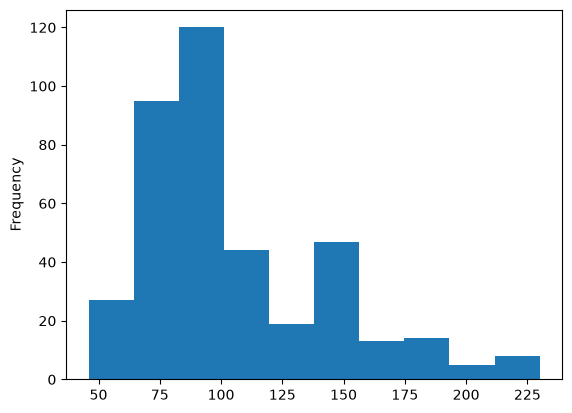

In [107]:
auto.horsepower.plot.hist()

In [109]:
# x / abs(max(x))
hp1 = auto.horsepower/abs(auto.horsepower.max())
hp1.describe()

count    392.000000
mean       0.454215
std        0.167353
min        0.200000
25%        0.326087
50%        0.406522
75%        0.547826
max        1.000000
Name: horsepower, dtype: float64

<Axes: ylabel='Frequency'>

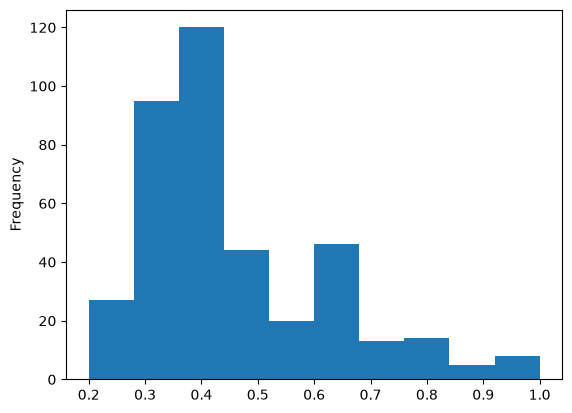

In [110]:
hp1.plot.hist()

#### min-max scaling : 최소값은 0, 최대값은 1이 되도록 변환

In [111]:
min_max = auto.horsepower.max() - auto.horsepower.min()
min_x = auto.horsepower - auto.horsepower.min()
hp2 = min_x / min_max
hp2.describe()

count    392.000000
mean       0.317768
std        0.209191
min        0.000000
25%        0.157609
50%        0.258152
75%        0.434783
max        1.000000
Name: horsepower, dtype: float64

<Axes: ylabel='Frequency'>

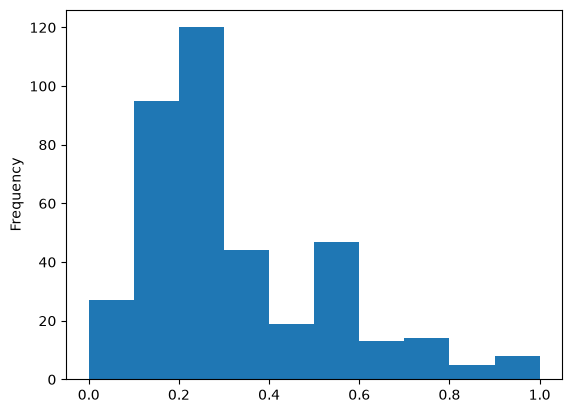

In [112]:
hp2.plot.hist()

#### 표준화(Standardization)

- Z-score 정규화
- 평균은 0, 표준편차는 1이 되도록 변환
- 이상치 파악

In [113]:
hp3 = (auto.horsepower - auto.horsepower.mean()) / auto.horsepower.std()
hp3.describe()

count    3.920000e+02
mean    -1.631348e-16
std      1.000000e+00
min     -1.519034e+00
25%     -7.656144e-01
50%     -2.849846e-01
75%      5.593651e-01
max      3.261284e+00
Name: horsepower, dtype: float64

<Axes: ylabel='Frequency'>

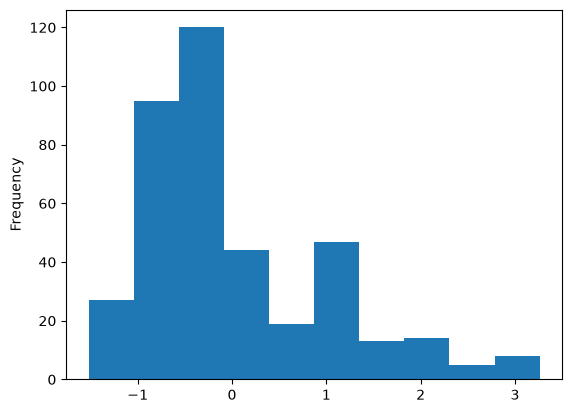

In [115]:
hp3.plot.hist()

<Axes: >

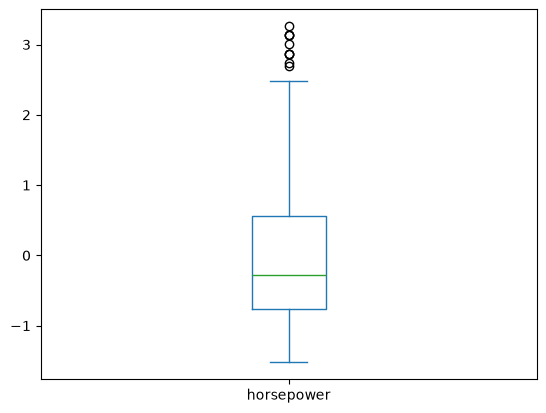

In [116]:
hp3.plot.box()

### 2-4. 시계열 데이터 처리

- 시계열 데이터를 데이터프레임의 행 인덱스로 사용하면 시간으로 기록된 데이터 분석에 매우 용이함
- Timestamp : 특정한 시점을 기록
- Period : 두 시점 사이의 일정한 기간

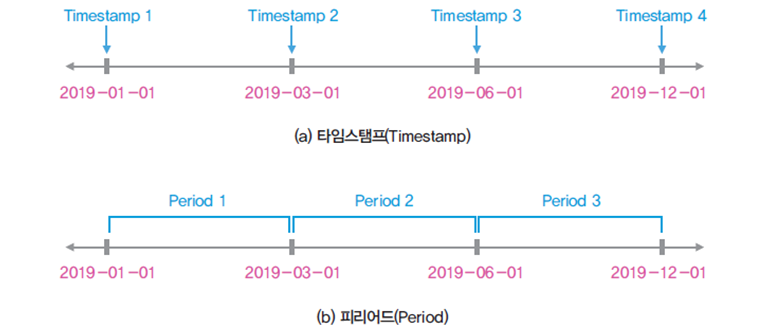

- 다른 자료형을 시계열 객체로 변환
    - 문자열을 Timestamp로 변환 : to_datetime()
    - Timestamp를 Period로 변환 : to_period()  
    
    

- 시계열 데이터 생성
    - Timestamp 배열 : date_range()
    - Period 배열 : period_range()
    
    

- 시계열 데이터 활용 : 날짜 데이터 분리, 날짜 인덱스 활용

https://pandas.pydata.org/docs/user_guide/timeseries.html

### 1) 다른 자료형을 시계열 객체로 변환

#### ① 문자열을 Timestamp로 변환 : pd.to_datetime()

to_datetime(arg, errors='raise', dayfirst=False, yearfirst=False, utc=None, format=None, exact=True, unit=None, infer_datetime_format=False, origin='unix', cache=True)

- datetime64 자료형으로 변환

https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html

#### 예제. 주식 거래 데이터(Netflex)

In [171]:
stock = pd.read_csv('data/NFLX.csv')
stock.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


In [118]:
stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 4874 entries, 0 to 4873
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4874 non-null   str    
 1   Open       4874 non-null   float64
 2   High       4874 non-null   float64
 3   Low        4874 non-null   float64
 4   Close      4874 non-null   float64
 5   Adj Close  4874 non-null   float64
 6   Volume     4874 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 266.7 KB


- Date 컬럼 : 문자열(object, str)을 Timestamp 객체로 변환

In [ ]:
stock['new_date'] = pd.to_datetime(stock['Date'])

#### 시계열값(Timestamp)을 인덱스로 설정
- 인덱스 및 슬라이싱하기 편리함

In [121]:
stock.set_index('new_date', inplace=True)

,Date,Open,High,Low,Close,Adj Close,Volume
new_date,,,,,,,
2018-06-01,2018-06-01,353.880005,359.989990,352.820007,359.929993,359.929993,7112300
2018-06-04,2018-06-04,362.679993,363.000000,355.510010,361.809998,361.809998,7682000
2018-06-05,2018-06-05,363.320007,369.829987,361.410004,365.799988,365.799988,8358000
2018-06-06,2018-06-06,367.779999,369.679993,363.329987,367.450012,367.450012,7712300
2018-06-07,2018-06-07,368.540009,368.700012,357.799988,361.399994,361.399994,8278000
2018-06-08,2018-06-08,358.059998,362.390015,356.250000,360.570007,360.570007,5225700
2018-06-11,2018-06-11,361.880005,365.670013,360.910004,361.450012,361.450012,4432400
2018-06-12,2018-06-12,363.600006,365.980011,362.000000,363.829987,363.829987,4291000
2018-06-13,2018-06-13,367.529999,384.250000,364.109985,379.929993,379.929993,18222800


- 2018년 6월 데이터 추출

In [122]:
stock.loc['2018.06']

,Date,Open,High,Low,Close,Adj Close,Volume
new_date,,,,,,,
2018-06-01,2018-06-01,353.880005,359.989990,352.820007,359.929993,359.929993,7112300
2018-06-04,2018-06-04,362.679993,363.000000,355.510010,361.809998,361.809998,7682000
2018-06-05,2018-06-05,363.320007,369.829987,361.410004,365.799988,365.799988,8358000
2018-06-06,2018-06-06,367.779999,369.679993,363.329987,367.450012,367.450012,7712300
2018-06-07,2018-06-07,368.540009,368.700012,357.799988,361.399994,361.399994,8278000
2018-06-08,2018-06-08,358.059998,362.390015,356.250000,360.570007,360.570007,5225700
2018-06-11,2018-06-11,361.880005,365.670013,360.910004,361.450012,361.450012,4432400
2018-06-12,2018-06-12,363.600006,365.980011,362.000000,363.829987,363.829987,4291000
2018-06-13,2018-06-13,367.529999,384.250000,364.109985,379.929993,379.929993,18222800


- 2018년 6월~7월 데이터 추출

In [123]:
stock.loc['2018.06':'2018.07']

,Date,Open,High,Low,Close,Adj Close,Volume
new_date,,,,,,,
2018-06-01,2018-06-01,353.880005,359.989990,352.820007,359.929993,359.929993,7112300
2018-06-04,2018-06-04,362.679993,363.000000,355.510010,361.809998,361.809998,7682000
2018-06-05,2018-06-05,363.320007,369.829987,361.410004,365.799988,365.799988,8358000
2018-06-06,2018-06-06,367.779999,369.679993,363.329987,367.450012,367.450012,7712300
2018-06-07,2018-06-07,368.540009,368.700012,357.799988,361.399994,361.399994,8278000
2018-06-08,2018-06-08,358.059998,362.390015,356.250000,360.570007,360.570007,5225700
2018-06-11,2018-06-11,361.880005,365.670013,360.910004,361.450012,361.450012,4432400
2018-06-12,2018-06-12,363.600006,365.980011,362.000000,363.829987,363.829987,4291000
2018-06-13,2018-06-13,367.529999,384.250000,364.109985,379.929993,379.929993,18222800


- 2018년 6월25일 ~7월10일 데이터 추출

In [124]:
stock.loc['2018.06.25':'2018.07.10']

,Date,Open,High,Low,Close,Adj Close,Volume
new_date,,,,,,,
2018-06-25,2018-06-25,404.690002,405.989990,378.750000,384.480011,384.480011,22490900
2018-06-26,2018-06-26,393.279999,404.779999,389.049988,399.390015,399.390015,15191200
2018-06-27,2018-06-27,407.559998,411.589996,390.000000,390.390015,390.390015,16541400
2018-06-28,2018-06-28,395.000000,396.899994,387.100006,395.420013,395.420013,12219900
2018-06-29,2018-06-29,399.190002,401.329987,390.549988,391.429993,391.429993,9252500
2018-07-02,2018-07-02,385.450012,398.380005,380.000000,398.179993,398.179993,8142500
2018-07-03,2018-07-03,399.489990,399.980011,389.500000,390.519989,390.519989,5280300
2018-07-05,2018-07-05,393.799988,399.239990,390.859985,398.390015,398.390015,8448900
2018-07-06,2018-07-06,397.450012,408.649994,395.519989,408.250000,408.250000,8629600


#### ② Timestamp를 Period로 변환 : Timestamp.to_period(freq='D'|'M'|'Y')

- Timestamp 객체를 일정한 기간을 나타내는 Period 객체로 변환
- DatetimeIndex가 PeriodIndex로 변환
- 자료형은 datetime64에서 period로 변환
- freq 옵션 : https://pandas.pydata.org/docs/user_guide/timeseries.html#timeseries-period-aliases

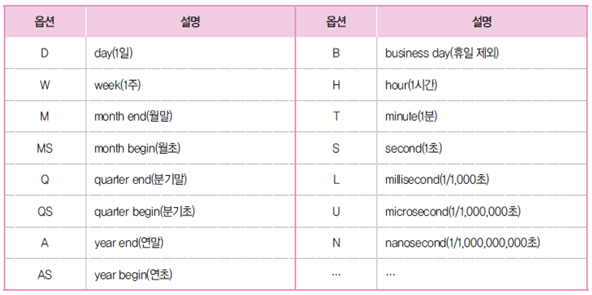

In [125]:
dates = ['2019-01-01', '2020-03-01', '2012-06-01']
ts_dates = pd.to_datetime(dates)
ts_dates

DatetimeIndex(['2019-01-01', '2020-03-01', '2012-06-01'], dtype='datetime64[us]', freq=None)

In [126]:
ts_dates.to_period(freq='D')

PeriodIndex(['2019-01-01', '2020-03-01', '2012-06-01'], dtype='period[D]')

In [128]:
ts_dates.to_period(freq='M')

PeriodIndex(['2019-01', '2020-03', '2012-06'], dtype='period[M]')

In [129]:
ts_dates.to_period(freq='Y')

PeriodIndex(['2019', '2020', '2012'], dtype='period[Y-DEC]')

In [131]:
ts_dates.to_period(freq='h')

PeriodIndex(['2019-01-01 00:00', '2020-03-01 00:00', '2012-06-01 00:00'], dtype='period[h]')

### 2) 시계열 데이터 생성

#### Timestamp 배열 생성 : date_range() 함수 사용

- date_range(start=None, end=None, periods=None, freq=None, tz=None, normalize=False, name=None, closed=_NoDefault.no_default, inclusive=None, **kwargs)
- DatetimeIndex 생성
- https://pandas.pydata.org/docs/reference/api/pandas.date_range.html

In [132]:
# 월초기준 : MS
pd.date_range(start='2020-01-01', periods=6, freq='MS', tz='Asia/Seoul')

DatetimeIndex(['2020-01-01 00:00:00+09:00', '2020-02-01 00:00:00+09:00',
               '2020-03-01 00:00:00+09:00', '2020-04-01 00:00:00+09:00',
               '2020-05-01 00:00:00+09:00', '2020-06-01 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='MS')

In [134]:
# 월말기준 : ME
pd.date_range(start='2020-01-01', periods=6, freq='ME', tz='Asia/Seoul')

DatetimeIndex(['2020-01-31 00:00:00+09:00', '2020-02-29 00:00:00+09:00',
               '2020-03-31 00:00:00+09:00', '2020-04-30 00:00:00+09:00',
               '2020-05-31 00:00:00+09:00', '2020-06-30 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='ME')

In [135]:
pd.date_range(start='2020-01-01', periods=6, freq='3D', tz='Asia/Seoul')

DatetimeIndex(['2020-01-01 00:00:00+09:00', '2020-01-04 00:00:00+09:00',
               '2020-01-07 00:00:00+09:00', '2020-01-10 00:00:00+09:00',
               '2020-01-13 00:00:00+09:00', '2020-01-16 00:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='3D')

In [136]:
pd.date_range(start='2020-01-01', periods=6, freq='10h', tz='Asia/Seoul')

DatetimeIndex(['2020-01-01 00:00:00+09:00', '2020-01-01 10:00:00+09:00',
               '2020-01-01 20:00:00+09:00', '2020-01-02 06:00:00+09:00',
               '2020-01-02 16:00:00+09:00', '2020-01-03 02:00:00+09:00'],
              dtype='datetime64[us, Asia/Seoul]', freq='10h')

#### Period 배열 생성 : period_range() 함수 사용

- period_range(start=None, end=None, periods=None, freq=None, name=None)
- PeriodIndex 생성
- https://pandas.pydata.org/docs/reference/api/pandas.period_range.html

In [137]:
pd.period_range(start='2020-01-01', periods=6, freq='M')

PeriodIndex(['2020-01', '2020-02', '2020-03', '2020-04', '2020-05', '2020-06'], dtype='period[M]')

In [138]:
pd.period_range(start='2020-01-01', periods=6, freq='D')

PeriodIndex(['2020-01-01', '2020-01-02', '2020-01-03', '2020-01-04',
             '2020-01-05', '2020-01-06'],
            dtype='period[D]')

In [139]:
pd.period_range(start='2020-01-01', periods=6, freq='h')

PeriodIndex(['2020-01-01 00:00', '2020-01-01 01:00', '2020-01-01 02:00',
             '2020-01-01 03:00', '2020-01-01 04:00', '2020-01-01 05:00'],
            dtype='period[h]')

In [140]:
pd.period_range(start='2020-01-01', periods=6, freq='10h')

PeriodIndex(['2020-01-01 00:00', '2020-01-01 10:00', '2020-01-01 20:00',
             '2020-01-02 06:00', '2020-01-02 16:00', '2020-01-03 02:00'],
            dtype='period[10h]')

In [142]:
pd.period_range(start='2020-01-01', periods=6, freq='10s')

PeriodIndex(['2020-01-01 00:00:00', '2020-01-01 00:00:10',
             '2020-01-01 00:00:20', '2020-01-01 00:00:30',
             '2020-01-01 00:00:40', '2020-01-01 00:00:50'],
            dtype='period[10s]')

### 3) 시계열 데이터 활용

#### 날짜 데이터 분리

- 연-월-일 정보를 연, 월, 일 각각으로 구분

In [143]:
stock.head()
stock.info()

,Date,Open,High,Low,Close,Adj Close,Volume
new_date,,,,,,,
2002-05-23,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
2002-05-24,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2002-05-28,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
2002-05-29,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
2002-05-30,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


<class 'pandas.DataFrame'>
DatetimeIndex: 4874 entries, 2002-05-23 to 2021-09-30
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4874 non-null   str    
 1   Open       4874 non-null   float64
 2   High       4874 non-null   float64
 3   Low        4874 non-null   float64
 4   Close      4874 non-null   float64
 5   Adj Close  4874 non-null   float64
 6   Volume     4874 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 433.7 KB


In [144]:
stock = stock.reset_index()

In [148]:
stock.head()
#stock = stock.drop('Date', axis = 1)

,new_date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


- **Timestamp 객체**는 연, 월, 일, 시, 분, 초로 추출가능
    - Series.dt.year
    - Series.dt.month
    - Series.dt.day
    - Series.dt.hour
    - Series.dt.minute
    - Series.dt.second

In [150]:
stock.new_date.dtype
type(stock.new_date)

dtype('<M8[us]')

pandas.Series

In [151]:
stock['Year'] = stock.new_date.dt.year
stock['Month'] = stock.new_date.dt.month
stock['Day'] = stock.new_date.dt.day

In [152]:
stock.head()

,new_date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,5,23
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,5,24
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,5,29
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,5,30


- **Period 객체**에서 연-월 또는 연도 추출

In [154]:
stock['date_year'] = stock.new_date.dt.to_period(freq='Y')
stock['date_month'] = stock.new_date.dt.to_period(freq='M')
stock['date_day'] = stock.new_date.dt.to_period(freq='D')
stock.head()
stock.info()

,new_date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,5,23,2002,2002-05,2002-05-23
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,5,24,2002,2002-05,2002-05-24
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28,2002,2002-05,2002-05-28
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,5,29,2002,2002-05,2002-05-29
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,5,30,2002,2002-05,2002-05-30


<class 'pandas.DataFrame'>
RangeIndex: 4874 entries, 0 to 4873
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   new_date    4874 non-null   datetime64[us]
 1   Open        4874 non-null   float64       
 2   High        4874 non-null   float64       
 3   Low         4874 non-null   float64       
 4   Close       4874 non-null   float64       
 5   Adj Close   4874 non-null   float64       
 6   Volume      4874 non-null   int64         
 7   Year        4874 non-null   int32         
 8   Month       4874 non-null   int32         
 9   Day         4874 non-null   int32         
 10  date_year   4874 non-null   period[Y-DEC] 
 11  date_month  4874 non-null   period[M]     
 12  date_day    4874 non-null   period[D]     
dtypes: datetime64[us](1), float64(5), int32(3), int64(1), period[D](1), period[M](1), period[Y-DEC](1)
memory usage: 438.0 KB


#### 날짜 인덱스 활용

In [156]:
stock.set_index('new_date', inplace = True)
stock.head()

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
new_date,,,,,,,,,,,,
2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,5,23,2002,2002-05,2002-05-23
2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,5,24,2002,2002-05,2002-05-24
2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28,2002,2002-05,2002-05-28
2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,5,29,2002,2002-05,2002-05-29
2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,5,30,2002,2002-05,2002-05-30


In [157]:
stock.loc['2018-12'][:3]

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
new_date,,,,,,,,,,,,
2018-12-03,293.190002,298.720001,284.579987,290.299988,290.299988,14117400,2018,12,3,2018,2018-12,2018-12-03
2018-12-04,288.130005,295.739990,274.720001,275.329987,275.329987,12800600,2018,12,4,2018,2018-12,2018-12-04
2018-12-06,268.329987,283.220001,267.140015,282.880005,282.880005,13074300,2018,12,6,2018,2018-12,2018-12-06


In [160]:
stock.loc['2018-6-20':'2018-6-25':2]

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
new_date,,,,,,,,,,,,
2018-06-20,415.149994,419.470001,409.600006,416.760010,416.760010,16494600,2018,6,20,2018,2018-06,2018-06-20
2018-06-22,419.980011,420.500000,409.649994,411.089996,411.089996,10428600,2018,6,22,2018,2018-06,2018-06-22


In [161]:
stock.index
stock.index.max()

DatetimeIndex(['2002-05-23', '2002-05-24', '2002-05-28', '2002-05-29',
               '2002-05-30', '2002-05-31', '2002-06-03', '2002-06-04',
               '2002-06-05', '2002-06-06',
               ...
               '2021-09-17', '2021-09-20', '2021-09-21', '2021-09-22',
               '2021-09-23', '2021-09-24', '2021-09-27', '2021-09-28',
               '2021-09-29', '2021-09-30'],
              dtype='datetime64[us]', name='new_date', length=4874, freq=None)

Timestamp('2021-09-30 00:00:00')

In [162]:
# 기준일자를 기반으로 일수를 인덱스로
recency = stock.index.max()
stock['time_delta'] = recency - stock.index
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4874 entries, 2002-05-23 to 2021-09-30
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   Open        4874 non-null   float64        
 1   High        4874 non-null   float64        
 2   Low         4874 non-null   float64        
 3   Close       4874 non-null   float64        
 4   Adj Close   4874 non-null   float64        
 5   Volume      4874 non-null   int64          
 6   Year        4874 non-null   int32          
 7   Month       4874 non-null   int32          
 8   Day         4874 non-null   int32          
 9   date_year   4874 non-null   period[Y-DEC]  
 10  date_month  4874 non-null   period[M]      
 11  date_day    4874 non-null   period[D]      
 12  time_delta  4874 non-null   timedelta64[us]
dtypes: float64(5), int32(3), int64(1), period[D](1), period[M](1), period[Y-DEC](1), timedelta64[us](1)
memory usage: 605.0 KB


In [163]:
stock.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4874 entries, 2002-05-23 to 2021-09-30
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype          
---  ------      --------------  -----          
 0   Open        4874 non-null   float64        
 1   High        4874 non-null   float64        
 2   Low         4874 non-null   float64        
 3   Close       4874 non-null   float64        
 4   Adj Close   4874 non-null   float64        
 5   Volume      4874 non-null   int64          
 6   Year        4874 non-null   int32          
 7   Month       4874 non-null   int32          
 8   Day         4874 non-null   int32          
 9   date_year   4874 non-null   period[Y-DEC]  
 10  date_month  4874 non-null   period[M]      
 11  date_day    4874 non-null   period[D]      
 12  time_delta  4874 non-null   timedelta64[us]
dtypes: float64(5), int32(3), int64(1), period[D](1), period[M](1), period[Y-DEC](1), timedelta64[us](1)
memory usage: 605.0 KB


In [165]:
stock.head()

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day,time_delta
new_date,,,,,,,,,,,,,
2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,5,23,2002,2002-05,2002-05-23,7070 days
2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,5,24,2002,2002-05,2002-05-24,7069 days
2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28,2002,2002-05,2002-05-28,7065 days
2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,5,29,2002,2002-05,2002-05-29,7064 days
2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,5,30,2002,2002-05,2002-05-30,7063 days


In [166]:
stock.set_index('time_delta', inplace = True)
stock.head(3)

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
time_delta,,,,,,,,,,,,
7070 days,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,5,23,2002,2002-05,2002-05-23
7069 days,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,5,24,2002,2002-05,2002-05-24
7065 days,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28,2002,2002-05,2002-05-28


In [167]:
stock['200 days':'180 days']

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
time_delta,,,,,,,,,,,,
199 days,516.320007,520.729980,508.029999,520.250000,520.250000,3484300,2021,3,15,2021,2021-03,2021-03-15
198 days,524.469971,533.419983,523.210022,524.030029,524.030029,3238900,2021,3,16,2021,2021-03,2021-03-16
197 days,522.000000,528.369995,514.299988,524.440002,524.440002,2817400,2021,3,17,2021,2021-03,2021-03-17
196 days,516.400024,517.900024,503.850006,504.790009,504.790009,4094500,2021,3,18,2021,2021-03,2021-03-18
195 days,504.959991,513.190002,501.630005,512.179993,512.179993,4386400,2021,3,19,2021,2021-03,2021-03-19
192 days,509.130005,529.309998,509.130005,523.109985,523.109985,3360600,2021,3,22,2021,2021-03,2021-03-22
191 days,529.869995,543.119995,529.400024,535.090027,535.090027,5583500,2021,3,23,2021,2021-03,2021-03-23
190 days,533.780029,534.419983,520.000000,520.809998,520.809998,4102200,2021,3,24,2021,2021-03,2021-03-24
189 days,516.989990,518.530029,497.000000,502.859985,502.859985,4926800,2021,3,25,2021,2021-03,2021-03-25


In [168]:
stock.sort_index()

,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,date_year,date_month,date_day
time_delta,,,,,,,,,,,,
0 days,608.049988,619.000000,608.049988,610.340027,610.340027,6612600,2021,9,30,2021,2021-09,2021-09-30
1 days,589.010010,609.880005,588.010010,599.059998,599.059998,6221000,2021,9,29,2021,2021-09,2021-09-29
2 days,589.000000,599.539978,580.159973,583.849976,583.849976,4431100,2021,9,28,2021,2021-09,2021-09-28
3 days,587.950012,593.580017,576.929993,592.640015,592.640015,2504700,2021,9,27,2021,2021-09,2021-09-27
6 days,592.500000,592.979980,583.640015,592.390015,592.390015,2124800,2021,9,24,2021,2021-09,2021-09-24
...,...,...,...,...,...,...,...,...,...,...,...,...
7063 days,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,5,30,2002,2002-05,2002-05-30
7064 days,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,5,29,2002,2002-05,2002-05-29
7065 days,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,5,28,2002,2002-05,2002-05-28


---------------------------------------

#### 참고. 날짜 문자열에서 str객체를 이용한 연,월,일 추출

- Series.str.split('-', expand=True)를 이용하여 연,월,일 컬럼으로 저장

In [172]:
stock.Date.str.split('-')
stock[['Year','Month','Day']] = stock.Date.str.split('-', expand=True)
stock.head(2)

0       [2002, 05, 23]
1       [2002, 05, 24]
2       [2002, 05, 28]
3       [2002, 05, 29]
4       [2002, 05, 30]
             ...      
4869    [2021, 09, 24]
4870    [2021, 09, 27]
4871    [2021, 09, 28]
4872    [2021, 09, 29]
4873    [2021, 09, 30]
Name: Date, Length: 4874, dtype: object

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,05,23
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,05,24


- Series.str.split('-')로 분할된 컬럼에서 인덱스로 해당위치 값들만 추출

In [173]:
stock.Date.str.split('-').tolist()

[['2002', '05', '23'],
 ['2002', '05', '24'],
 ['2002', '05', '28'],
 ['2002', '05', '29'],
 ['2002', '05', '30'],
 ['2002', '05', '31'],
 ['2002', '06', '03'],
 ['2002', '06', '04'],
 ['2002', '06', '05'],
 ['2002', '06', '06'],
 ['2002', '06', '07'],
 ['2002', '06', '10'],
 ['2002', '06', '11'],
 ['2002', '06', '12'],
 ['2002', '06', '13'],
 ['2002', '06', '14'],
 ['2002', '06', '17'],
 ['2002', '06', '18'],
 ['2002', '06', '19'],
 ['2002', '06', '20'],
 ['2002', '06', '21'],
 ['2002', '06', '24'],
 ['2002', '06', '25'],
 ['2002', '06', '26'],
 ['2002', '06', '27'],
 ['2002', '06', '28'],
 ['2002', '07', '01'],
 ['2002', '07', '02'],
 ['2002', '07', '03'],
 ['2002', '07', '05'],
 ['2002', '07', '08'],
 ['2002', '07', '09'],
 ['2002', '07', '10'],
 ['2002', '07', '11'],
 ['2002', '07', '12'],
 ['2002', '07', '15'],
 ['2002', '07', '16'],
 ['2002', '07', '17'],
 ['2002', '07', '18'],
 ['2002', '07', '19'],
 ['2002', '07', '22'],
 ['2002', '07', '23'],
 ['2002', '07', '24'],
 ['2002', '

- Series.str.split('-')으로 분할한 후 tolist()함수를 적용하여 리스트로 변환한 후 새로운 데이터프레임으로 생성

In [174]:
stock.Date.str.split('-').tolist()[:3]
pd.DataFrame(stock.Date.str.split('-').tolist(), columns=['Year', 'Month', 'Day'])

[['2002', '05', '23'], ['2002', '05', '24'], ['2002', '05', '28']]

,Year,Month,Day
0,2002,05,23
1,2002,05,24
2,2002,05,28
3,2002,05,29
4,2002,05,30
...,...,...,...
4869,2021,09,24
4870,2021,09,27
4871,2021,09,28
4872,2021,09,29


- Series.str.split('-')으로 분할한 결과에 apply(pd.Series)를 적용하여 데이터프레임을 생성

In [176]:
stock.Date.str.split('-').apply(pd.Series)

,0,1,2
0,2002,05,23
1,2002,05,24
2,2002,05,28
3,2002,05,29
4,2002,05,30
...,...,...,...
4869,2021,09,24
4870,2021,09,27
4871,2021,09,28
4872,2021,09,29


In [178]:
new_df = stock.Date.str.split('-').apply(pd.Series)
new_df.columns = ['Year2', 'Month2', 'Day2']

In [179]:
new_df.index = stock.index
new_df.head()

,Year2,Month2,Day2
0,2002,05,23
1,2002,05,24
2,2002,05,28
3,2002,05,29
4,2002,05,30


In [180]:
stock.join(new_df)
stock.head(3)

,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Year2,Month2,Day2
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,05,23,2002,05,23
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,05,24,2002,05,24
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,05,28,2002,05,28
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800,2002,05,29,2002,05,29
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200,2002,05,30,2002,05,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4869,2021-09-24,592.500000,592.979980,583.640015,592.390015,592.390015,2124800,2021,09,24,2021,09,24
4870,2021-09-27,587.950012,593.580017,576.929993,592.640015,592.640015,2504700,2021,09,27,2021,09,27
4871,2021-09-28,589.000000,599.539978,580.159973,583.849976,583.849976,4431100,2021,09,28,2021,09,28
4872,2021-09-29,589.010010,609.880005,588.010010,599.059998,599.059998,6221000,2021,09,29,2021,09,29


,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000,2002,05,23
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800,2002,05,24
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400,2002,05,28


---

#### 참고. 시계열 데이터 전처리 4단계
1. resample : 시간 정렬
   - 원시 시계열 데이터는
       - 불규칙 샘플링(예. 센서 이벤트 기반)
       - 누락 시간 존재
       - 데이터가 너무 촘촘(초단위)하거나 너무 듬성(일단위)
   - 분석 단위로 시간축을 표준화 : 예. 1분 / 10분 / 1시간 / 1일
   - 시간단위로 집계 : 다운 샘플링 -> Series.resample('10min')
   - 누락 처리 : 빈 시간 채우기 -> 평균으로 채우거나 앞뒤값으로 ffill() / 보간법 -> interpolate()  

2. smoothing : 잡음 제거/노이즈 필터링
    - 노이즈(noise)는 단기 변동 키워서 추세/계절성 파악 방해, 이상탐지 방해, 모델학습 불안정
    - 추세는 살리고, 변동은 줄이는 처리
    - 이동평균(Moving Average: Rolling Mean) : rolling()
    - 지수이동평균(EWMA) : ewm()
    - 중앙값 필터 : 이상치/스파이크에 강함

3. differencing : 추세 제거 / 정상성 강화
   - 시계열 모델이나 패턴분석에서 추세(trend)가 강하면
       - 평균/분산이 시간에 따라 변함(정상성)
       - 상관구조 해석이 어려움
       - 변동(증감) 자체가 더 중요한 경우가 많음
    - 차분(differencing)으로 변화량을 분석 : diff()
        - 1차 차분
        - 계절 차분
        - 로그변환 + 차분(스케일 안정화)
        - 비율변화 : pct_change()

4. binning : 구간화 / 패턴 분석을 위한 범주화
   - 연속형 값을 레벨/상태로 바꾸면
       - 패턴이 훨씬 해석 쉬움(예. 낮음/보통/높음)
       - 상태 기반 규칙/알람
       - 마코프 전이(상태 전이) 분석 가능
    - cut(), qcut(), value_counts()

---